# Stillwater GWI/RDII Heterogeneity Project Sibling

This notebook creates a SewerTris project sibling from the completed Stillwater base model. The physical city layout, roads, DEM, sewer network, pipe design, and base hydraulic properties are reused. Only the dynamic SWMM input data are changed:

- GWI is assigned from a spatial raster of pipe inflow coefficients.
- RDII imperviousness is assigned from a spatial RDII density raster.

This is the project-style version of the idea explored in `Full_SewerTris_04.ipynb`, with the GWI raster applied directly to the scenario input that is actually simulated.

## Setup

Load the local refactored package and the completed Stillwater base project.

In [1]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import rasterio

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src" / "sewertris").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

EXAMPLES_DIR = PROJECT_ROOT / "examples"
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import sewertris

for _module_name in [
    "sewertris._deps",
    "sewertris.domain",
    "sewertris.layout",
    "sewertris.roads",
    "sewertris.topography",
    "sewertris.sewer_network",
    "sewertris.hydrology",
    "sewertris.design",
    "sewertris.swmm",
    "sewertris.plots",
    "sewertris.project",
    "sewertris",
]:
    if _module_name in sys.modules:
        importlib.reload(sys.modules[_module_name])

import sewertris as sp

base_project_path = EXAMPLES_DIR / "output_example_2_project"

base_project = sp.SewerTrisProject.load(base_project_path)
print("Base project:", base_project.project_file)


Base project: /Users/kevinblanco/Documents/Sewertris/examples/output_example_2_project/sewertris_project.json


## Define Sibling

The `changes` dictionary only touches Step 10 dynamic inputs, so the sibling reuses the completed physical system and rebuilds the SWMM scenario with heterogeneous GWI/RDII inputs.

In [2]:
heterogeneity_changes = {
    "gwi_raster": {
        "min_value": 0.00001,
        "max_value": 0.00005,
        "random_seed": 42,
        "n_hills": 1,
        "hill_min_value": 0.00003,
        "hill_max_value": 0.00006,
        "hill_radius_min": 250,
        "hill_radius_max": 250,
        "samples_per_pipe": 5,
        "clip_to_range": True,
    },
    "rdii_raster": {
        "min_density":0.0,
        "max_density": 3.0,
        "random_seed": 123,
        "n_hills": 2,
        "hill_min_density": 0.0,
        "hill_max_density": 4.0,
        "hill_radius_min": 250,
        "hill_radius_max": 250,
        "clip_to_range": True,
        "rdii_to_imperv_scale": (0.0, 100.0)
    },
    "rdii": {
        "infiltration_params": (15, 0.5, 7, "", ""),
        "width": 100,
        "slope": 0.005,
        "curblen": 0,
    },
}

project = base_project.clone_sibling(
    EXAMPLES_DIR / "output_example_4_project",
    name="Stillwater GWI/RDII Heterogeneity Project",
    changes=heterogeneity_changes,
)

print("Sibling project:", project.project_file)
print("Rerun from:", project.metadata["lineage"]["rerun_from"])
print("Copied artifacts:", project.metadata["lineage"]["copied_artifacts"])


Sibling project: /Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/sewertris_project.json
Rerun from: 10_dynamic_flow_input_definition_base_model
Copied artifacts: {'domain_mask': '/Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/state/domain_mask.npy', 'grid_meta': '/Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/state/grid_meta.json', 'layout_blocks': '/Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/city_layout.gpkg', 'city_blocks': '/Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/city_blocks.gpkg', 'road_centerlines': '/Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/road_centerlines.gpkg', 'road_polygons': '/Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/road_polygons.gpkg', 'road_boundary_lines': '/Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/road_boundary_lines.gpkg', 'road_outer_shell

## Run Sibling

Rerun the dynamic-input workflow using parent parameters plus the raster heterogeneity changes. The GWI raster and RDII raster are generated inside `output_example_4_project` and applied to the scenario SWMM file in-place.

In [3]:
results = project.rerun_from_parent_parameters(
    base_project,
    scenario_name="bwf_gwi_rdii",
    run_flow_components=True,
)

scenario = results["scenario"]
df = results["flow_components"]

print("GWI raster:", project.gwi_raster_path)
print("RDII raster:", project.rdii_raster_path)
print("Scenario input:", scenario.swmm_inp_path)
print("Flow components:", scenario.flows_path)


✅ SWMM .inp file written to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/sewer_model.inp
✅ Updated [DWF] with patterns "1" "2" "3" "4"
✅ Rewrote [PATTERNS] with HOURLY, DAILY, MONTHLY, WEEKEND
   Output saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/scenarios/bwf_gwi_rdii/sewer_model.inp
Random inflow raster with hills saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/gwi_inflow_coefficients.tif
✅ INFLOWS assigned based on raster and pipe length. Output: /Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/scenarios/bwf_gwi_rdii/sewer_model.inp
✅ RDII density raster saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/rdii_density.tif
✅ SWMM .inp file updated with RDII-based impervious percentages and saved to: /Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/scenarios/bwf_gwi_rdii/sewer_model.inp
✅ Tagged inp writte

## Inspect Heterogeneity Rasters

These rasters are the only intended model input changes relative to the Stillwater base project.

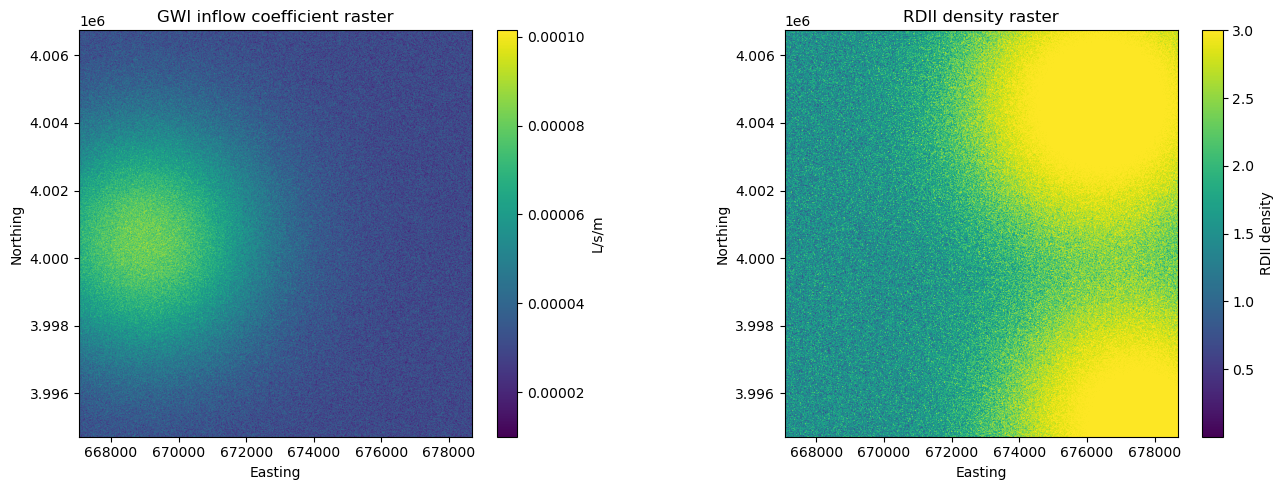

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, raster_path, title, label in [
    (axes[0], project.gwi_raster_path, "GWI inflow coefficient raster", "L/s/m"),
    (axes[1], project.rdii_raster_path, "RDII density raster", "RDII density"),
]:
    with rasterio.open(raster_path) as src:
        data = src.read(1)
        bounds = src.bounds
    im = ax.imshow(
        data,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top],
        origin="upper",
        cmap="viridis",
    )
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)

plt.tight_layout()
plt.show()


## Flow Components

Plot the decomposed hydrograph for the heterogeneous GWI/RDII scenario.

rainfall_data=[
    ('1/2/2025', '00:00', 0.0),
    ('1/2/2025', '01:00', 0.055),
    ('1/2/2025', '02:00', 0.055),
    ('1/2/2025', '03:00', 0.065),
    ('1/2/2025', '04:00', 0.065),
    ('1/2/2025', '05:00', 0.075),
    ('1/2/2025', '06:00', 0.085),
    ('1/2/2025', '07:00', 0.095),
    ('1/2/2025', '08:00', 0.105),
    ('1/2/2025', '09:00', 0.135),
    ('1/2/2025', '10:00', 0.17),
    ('1/2/2025', '11:00', 0.27),
    ('1/2/2025', '12:00', 2.14),
    ('1/2/2025', '13:00', 0.545),
    ('1/2/2025', '14:00', 0.24),
    ('1/2/2025', '15:00', 0.17),
    ('1/2/2025', '16:00', 0.13),
    ('1/2/2025', '17:00', 0.11),
    ('1/2/2025', '18:00', 0.095),
    ('1/2/2025', '19:00', 0.085),
    ('1/2/2025', '20:00', 0.07),
    ('1/2/2025', '21:00', 0.065),
    ('1/2/2025', '22:00', 0.06),
    ('1/2/2025', '23:00', 0.06),
    ('1/3/2025', '00:00', 0.055),
]


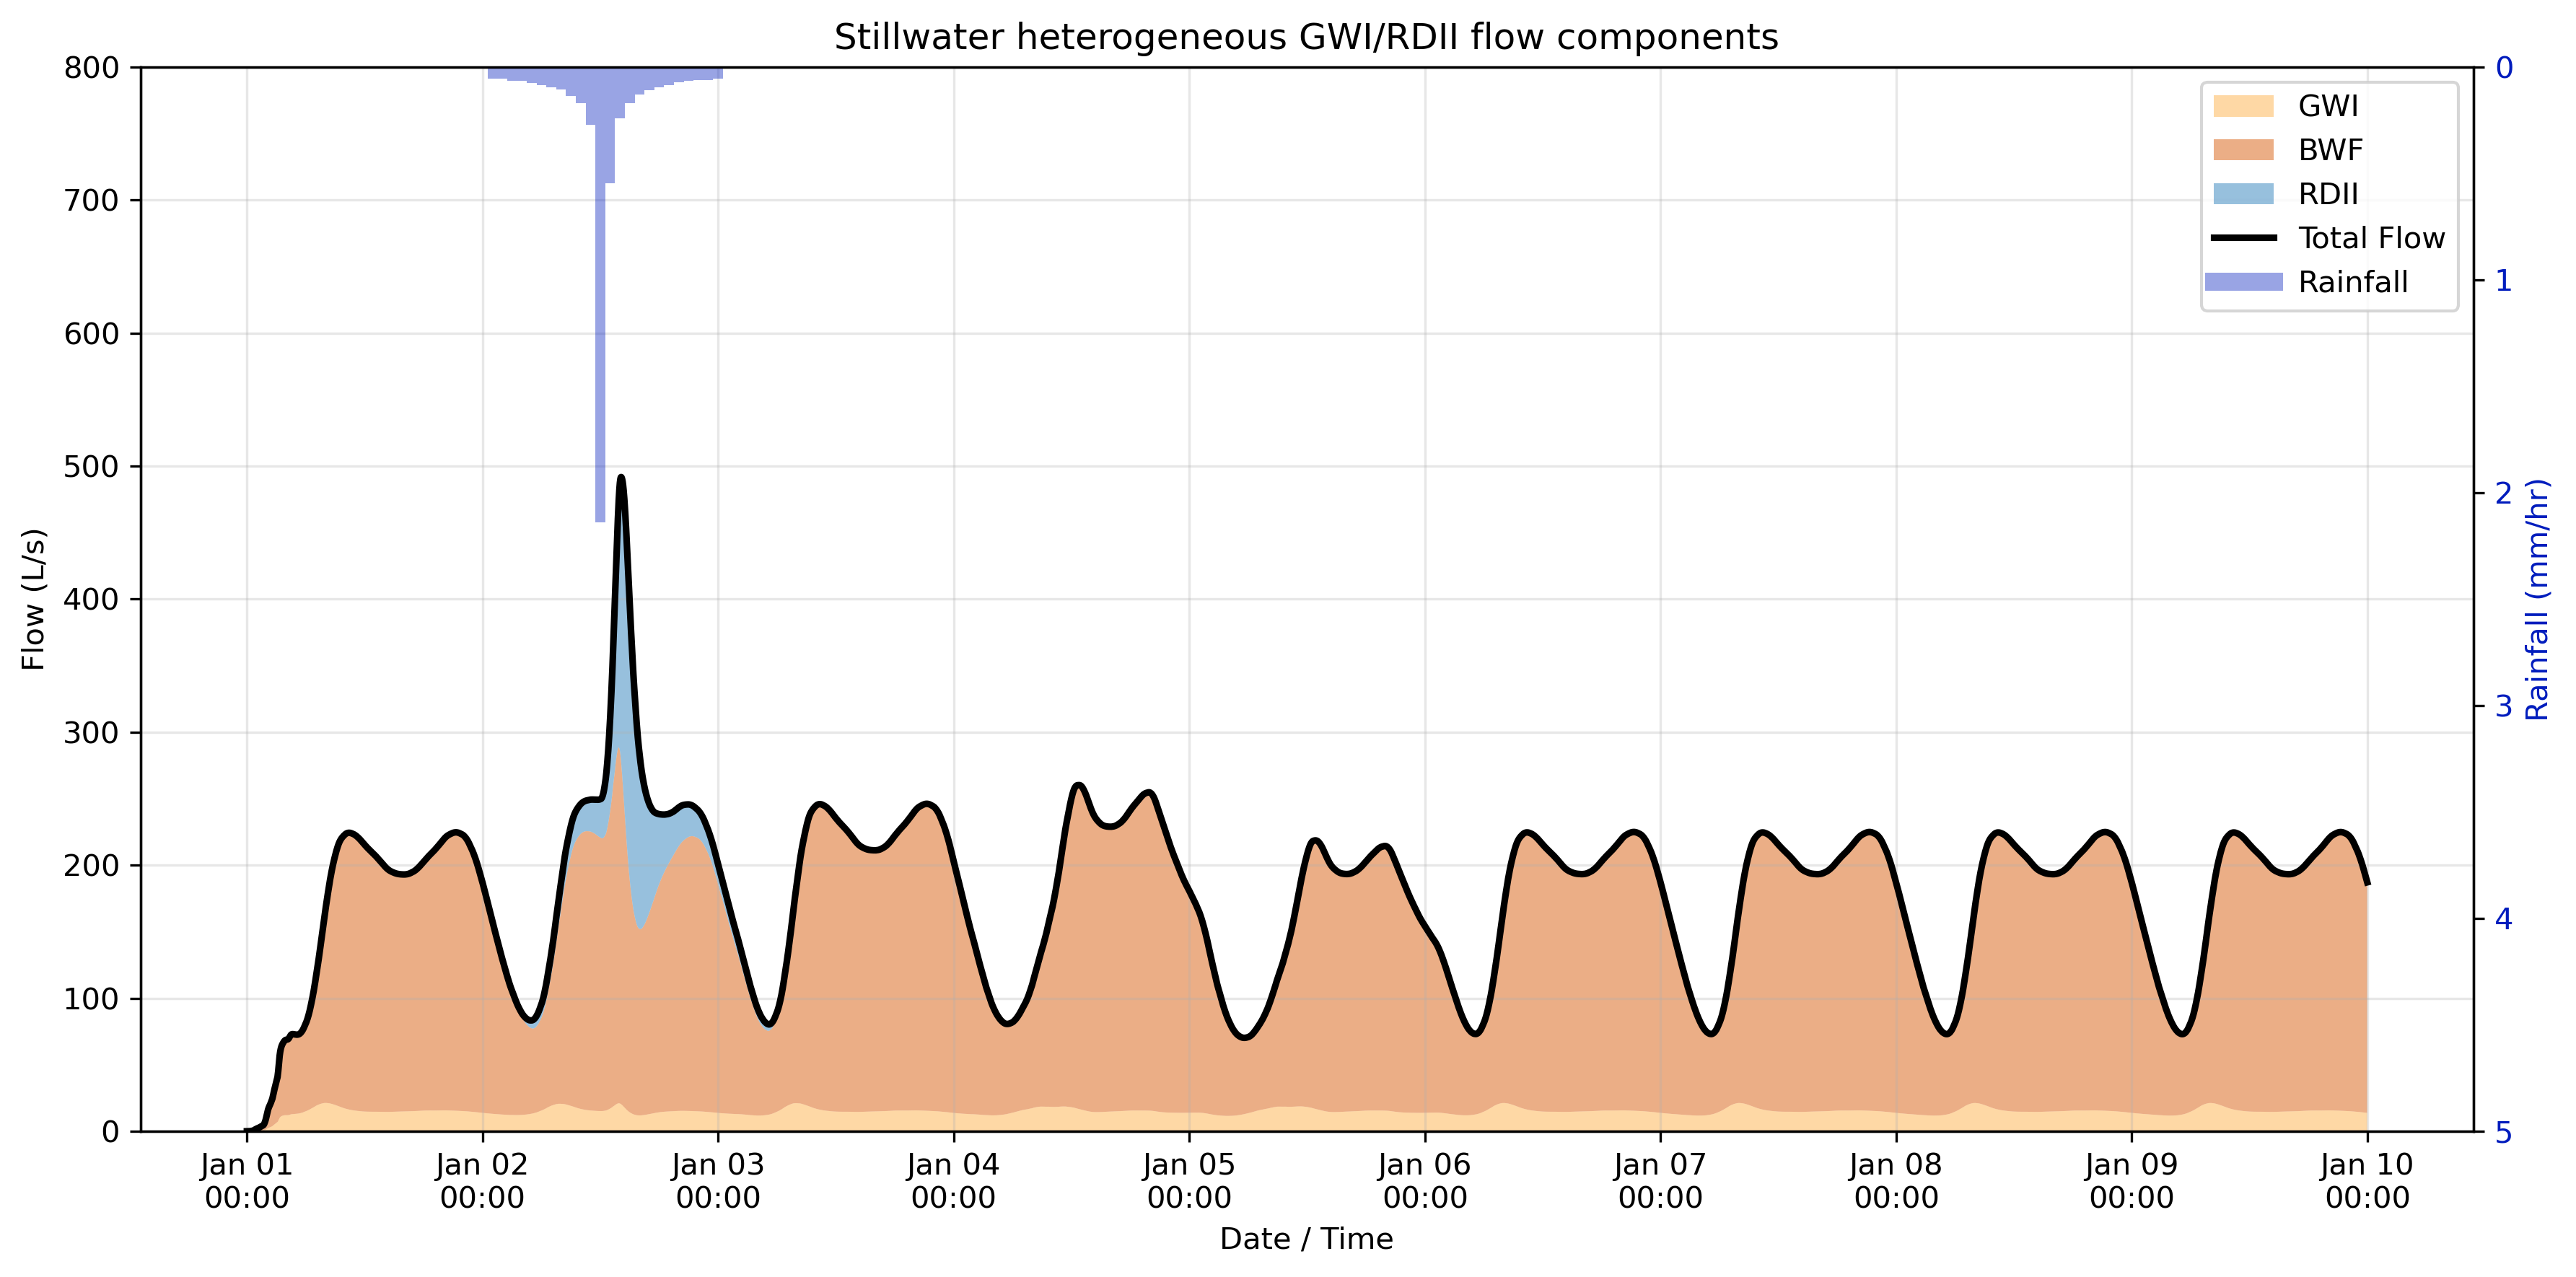

Project metadata: /Users/kevinblanco/Documents/Sewertris/examples/output_example_4_project/sewertris_project.json


In [5]:
options = base_project.step_parameters("10_dynamic_flow_input_definition_base_model").get("options_dict", {})
start = f"{options.get('START_DATE', '01/01/1990')} {options.get('START_TIME', '00:00:00')}"
end = f"{options.get('END_DATE', '01/10/1990')} {options.get('END_TIME', '00:00:00')}"

# ============================================================
# USER INPUTS
# ============================================================
P_total = 5.0  # total rainfall depth in mm
storm_start = "1/2/2025 00:00"

# ============================================================
# SCS / NRCS TYPE II 24-HOUR DISTRIBUTION
# 30-minute cumulative fractions
# ============================================================
# time_hr = [
#     0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5,
#     4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5,
#     8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5,
#     12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5,
#     16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5,
#     20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5,
#     24.0
# ]

# cum_fraction = [
#     0.000, 0.005, 0.011, 0.017, 0.023, 0.029, 0.035, 0.041,
#     0.048, 0.056, 0.064, 0.072, 0.080, 0.089, 0.098, 0.108,
#     0.120, 0.133, 0.147, 0.163, 0.181, 0.204, 0.235, 0.283,
#     0.500, 0.717, 0.765, 0.796, 0.819, 0.837, 0.853, 0.867,
#     0.880, 0.892, 0.902, 0.911, 0.920, 0.928, 0.936, 0.944,
#     0.952, 0.959, 0.965, 0.971, 0.977, 0.983, 0.989, 0.995,
#     1.000
# ]

time_hr = [
    0.0, 1.0, 2.0, 3.0,
    4.0, 5.0, 6.0, 7.0,
    8.0, 9.0, 10.0, 11.0,
    12.0, 13.0, 14.0, 15.0,
    16.0, 17.0, 18.0, 19.0,
    20.0, 21.0, 22.0, 23.0,    
    24.0
]

cum_fraction = [
    0.000, 0.011, 0.022, 0.035,
    0.048, 0.063, 0.080, 0.099,
    0.120, 0.147, 0.181, 0.235,
    0.663, 0.772, 0.820, 0.854,
    0.880, 0.902, 0.921, 0.938,
    0.952, 0.965, 0.977, 0.989,
    1.000
]

# ============================================================
# CREATE DATAFRAME
# ============================================================
df_r = pd.DataFrame({
    "time_hr": time_hr,
    "cum_fraction": cum_fraction
})

df_r["cum_rain_mm"] = df_r["cum_fraction"] * P_total
df_r["rain_mm"] = df_r["cum_rain_mm"].diff().fillna(0).round(3)

# ============================================================
# CREATE DATE/TIME FORMAT
# ============================================================
df_r["datetime"] = pd.date_range(
    start=pd.Timestamp(storm_start),
    periods=len(df_r),
    freq="60min"
)

rainfall_data = [
    (
        dt.strftime("%-m/%-d/%Y"),
        dt.strftime("%H:%M"),
        rain
    )
    for dt, rain in zip(df_r["datetime"], df_r["rain_mm"])
]

# ============================================================
# PRINT AS PYTHON LIST
# ============================================================
print("rainfall_data=[")
for row in rainfall_data:
    print(f"    {row},")
print("]")

sp.plot_flow_components_v2(
    df,
    rain=rainfall_data,
    start=start,
    end=end,
    title="Stillwater heterogeneous GWI/RDII flow components",
    flow_units="L/s",
    stack_components=True,
    flow_min=0,
    flow_max=800,
    rain_min=0,
    rain_max=5
)
project.save()
print("Project metadata:", project.project_file)


## Compare Base vs Heterogeneous Inputs

Because the physical system is reused, the most informative comparison plots are the SWMM inflow map and the flow-component hydrograph.

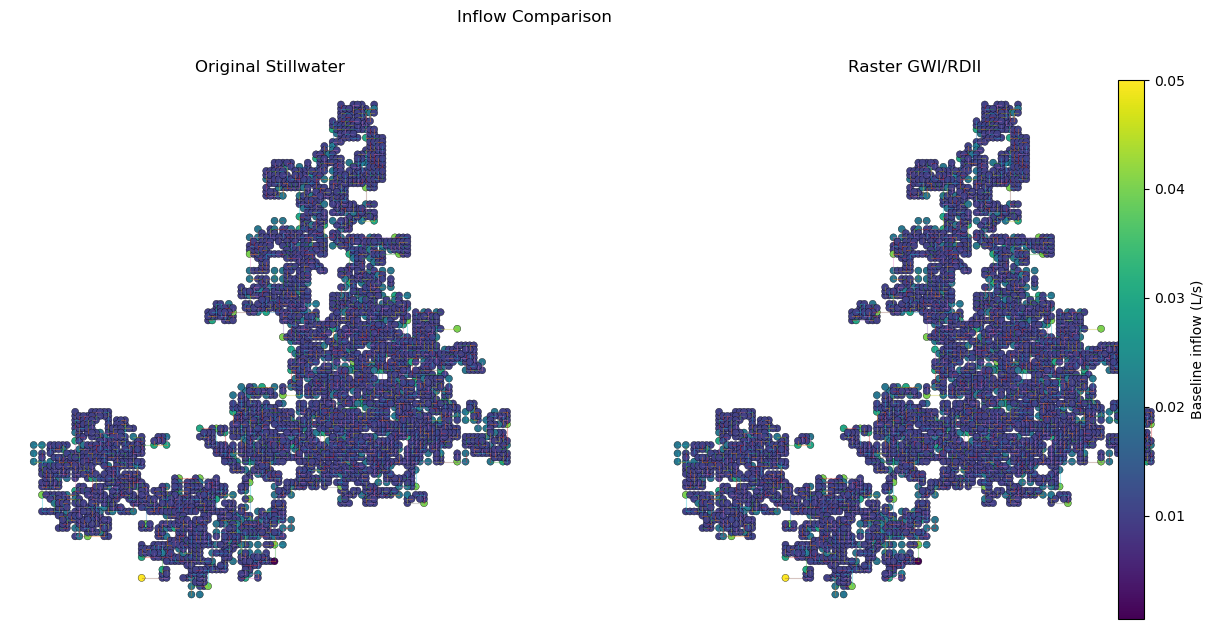

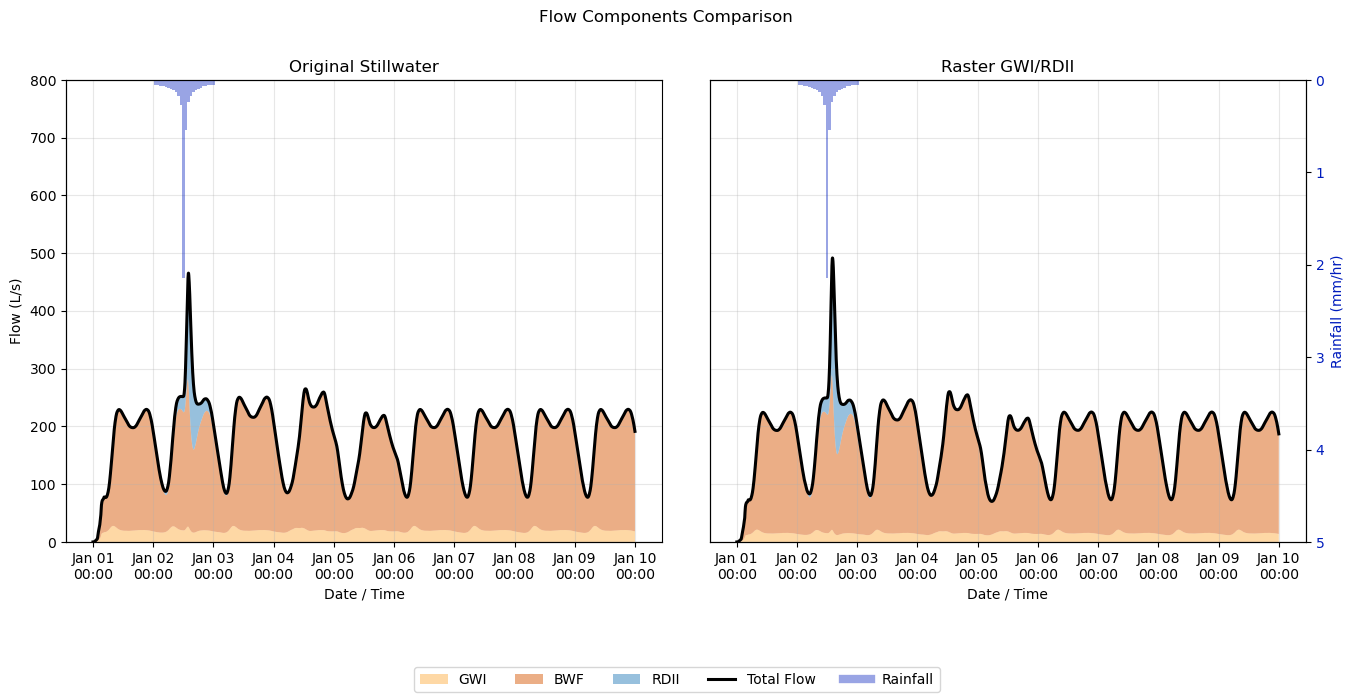

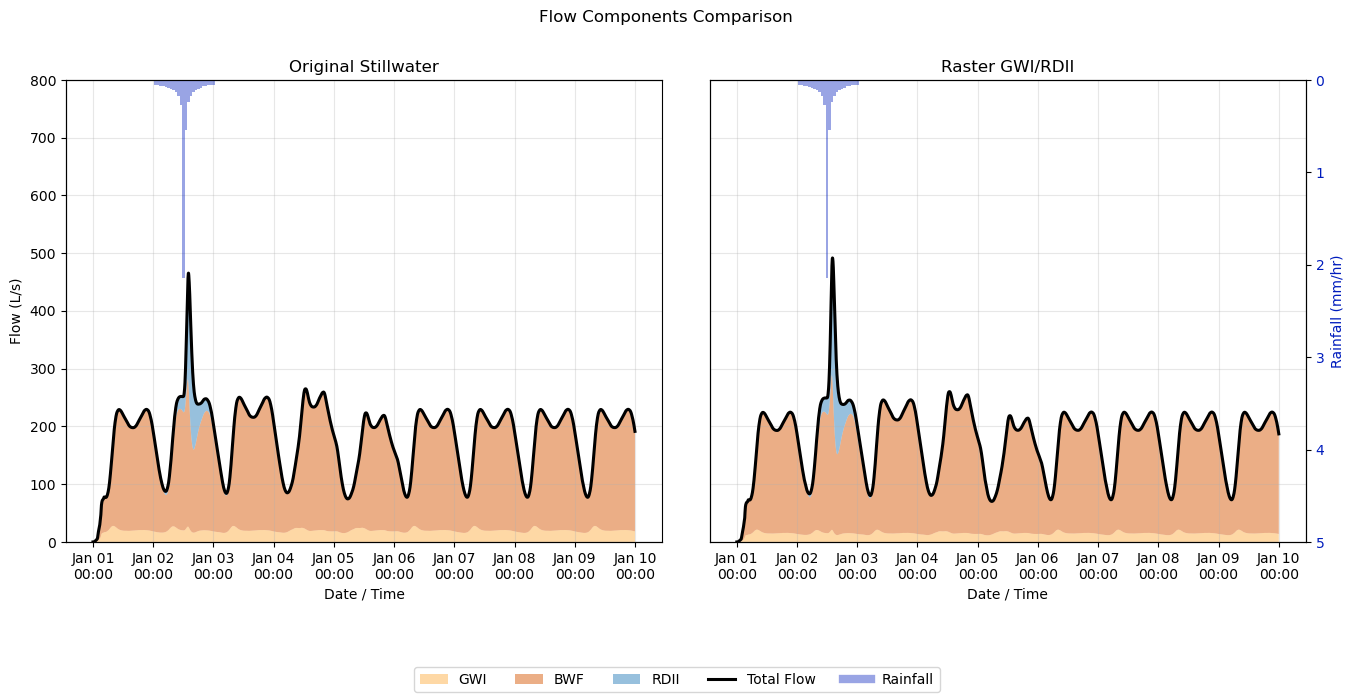

In [6]:
sp.plot_two_models(
    "inflow",
    base_project,
    project,
    labels=("Original Stillwater", "Raster GWI/RDII"),
    scenario_name="bwf_gwi_rdii",
)

sp.plot_two_models(
    "flow_components",
    base_project,
    project,
    labels=("Original Stillwater", "Raster GWI/RDII"),
    scenario_name="bwf_gwi_rdii",
    start=start,
    end=end,
    rain=rainfall_data,
    flow_min=0,
    flow_max=800,
    rain_min=0,
    rain_max=5
)


In [7]:
import os

# Your code here
# ...

os.system('afplay /System/Library/Sounds/Hero.aiff')
os.system('say "Kevin, your simulation has finished."')

0